In [1]:
import yaml
import time
import numpy as np
from pyrpl import Pyrpl
from lmfit.models import Model
import matplotlib.pyplot as plt
from yamlcore import CoreLoader

def ch1_fit_function(time, amp, freq, phase, offset):
    return amp * np.cos(2 * np.pi * freq * time + phase) + offset

def ch2_fit_function(time, amp, freq, phase, offset):
    return amp * np.sin(2 * np.pi * freq * time + phase) + offset

ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40110000 to _reads value 16384 by client 1


In [ ]:
class RPLockboxMZI(Pyrpl):
    def __init__(self, hostname, yml_file, gui=False, config_file='travis_global_config.yml'):
        super().__init__(hostname=hostname, gui=gui, config=config_file)
        self.setup_all_modules(yml_file)

    def setup_all_modules(self, yml_file):
        self.get_module_settings(yml_file)
        self.apply_settings()

    def apply_settings(self):
        if not hasattr(self, 'settings'):
            raise ValueError("Module settings not loaded. Please load settings first.")
        
        for module in self.settings.keys():
            getattr(self.rp, module).setup(**self.settings[module])

    def get_module_settings(self, yml_file):
        with open(yml_file, 'r') as stream:
            try:
                self.settings = yaml.load(stream, Loader=CoreLoader)
            except yaml.YAMLError as exc:
                raise ValueError(f"Error loading YAML file: {exc}")
            
    def calibrate_iq_amplitudes(self):
        self.rp.asg0.setup(output_direct='out1', amplitude=1.0)
        self.rp.scope.setup(duration = 2/self.rp.asg0.frequency, trigger_source='immediately', input1='iq0', input2='iq1', ch_math_active=False)
        self.rp.scope.single()
        calib_data_ch1, calib_data_ch2 = self.rp.scope.save_curve()
        self.rp.asg0.output_direct = 'off'

        self.filter_and_save_calibration_data(calib_data_ch1, calib_data_ch2)
        self.fit_calibration_data()
        if not self.fit_result_calib_ch1.success or not self.fit_result_calib_ch2.success:
            raise ValueError("Calibration fit failed. Check the data and fit functions.")
        
    def calibrate_signal_amplitudes(self):
        self.rp.asg0.setup(output_direct='out1')
        self.rp.iq0.setup(output_direct='off')
        self.rp.scope.setup(duration = 2/self.rp.asg0.frequency, trigger_source='immediately', input1='in1', input2='in2', ch_math_active=False)
        self.rp.scope.single()
        in1_curve, in2_curve = self.rp.scope.save_curve()
        self.rp.iq0.setup(output_direct='out1')
        cal_time_data, self.in1_cal_data = in1_curve.data
        _, self.in2_cal_data = in2_curve.data

        time_filter_cond = np.logical_and(
            cal_time_data > 0.15 / self.rp.asg0.frequency,
            cal_time_data < 0.35 / self.rp.asg0.frequency
        )
        cal_time_data = cal_time_data[time_filter_cond]
        self.in1_cal_data = self.in1_cal_data[time_filter_cond]
        self.in2_cal_data = self.in2_cal_data[time_filter_cond]

        model_ch1 = Model(ch1_fit_function, independent_vars=['time'])
        params_ch1 = model_ch1.make_params(amp=1, freq=0.5, phase=0, offset=0)
        self.fit_result_in1 = model_ch1.fit(self.in1_cal_data, params_ch1, time=cal_time_data)

        model_ch2 = Model(ch2_fit_function, independent_vars=['time'])
        params_ch2 = model_ch2.make_params(amp=1, freq=0.5, phase=0, offset=0)
        self.fit_result_in2 = model_ch2.fit(self.in2_cal_data, params_ch2, time=cal_time_data)

    def filter_and_save_calibration_data(self, calib_data_ch1, calib_data_ch2):   
        self.calib_data_time, self.calib_data_ch1 = calib_data_ch1.data
        self.calib_data_time, self.calib_data_ch2 = calib_data_ch2.data

        self.calib_gain_ch1 = self.rp.iq0.quadrature_factor
        self.calib_gain_ch2 = self.rp.iq1.quadrature_factor

        # Condition for masking only the most linear part of the increasing ramp
        time_filter_cond = np.logical_and(
            self.calib_data_time > 0.1 / self.rp.asg0.frequency,
            self.calib_data_time < 0.4 / self.rp.asg0.frequency
        )

        self.calib_data_time = self.calib_data_time[time_filter_cond]
        self.calib_data_ch1 = self.calib_data_ch1[time_filter_cond]
        self.calib_data_ch2 = self.calib_data_ch2[time_filter_cond]

    def fit_calibration_data(self):
        model_ch1 = Model(ch1_fit_function, independent_vars=['time'])
        params_ch1 = model_ch1.make_params(amp=1, freq=3.5, phase=0, offset=0)
        params_ch1['phase'].set(min=-np.pi, max=np.pi, vary=True)
        params_ch1['offset'].set(min=-0.25, max=0.25, vary=True)
        params_ch1['amp'].set(min=-1, max=1, vary=True)
        params_ch1['freq'].set(min=0, max=10, vary=True)
        self.fit_result_calib_ch1 = model_ch1.fit(self.calib_data_ch1, params_ch1, time=self.calib_data_time)

        model_ch2 = Model(ch2_fit_function, independent_vars=['time'])
        params_ch2 = model_ch2.make_params(amp=1, freq=self.fit_result_calib_ch1.params['freq'].value, phase=self.fit_result_calib_ch1.params['phase'].value, offset=0)
        params_ch2['phase'].set(min=self.fit_result_calib_ch1.params['phase'].value - 0.1, max=self.fit_result_calib_ch1.params['phase'].value + 0.1, vary=True)
        params_ch2['offset'].set(min=-0.25, max=0.25, vary=True)
        if params_ch1['amp'].value > 0:
            params_ch2['amp'].set(min=0, max=1, vary=True)
        else:
            params_ch2['amp'].set(min=-1, max=0, vary=True)
        # params_ch2['amp'].set(min=-1, max=1, vary=True)
        params_ch2['freq'].set(min=0, max=10, vary=True)
        self.fit_result_calib_ch2 = model_ch2.fit(self.calib_data_ch2, params_ch2, time=self.calib_data_time)

    def plot_calibration(self):
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        phi1 = 2 * np.pi * self.fit_result_calib_ch1.params['freq'].value * self.calib_data_time + self.fit_result_calib_ch1.params['phase'].value
        phi2 = 2 * np.pi * self.fit_result_calib_ch2.params['freq'].value * self.calib_data_time + self.fit_result_calib_ch2.params['phase'].value

        if np.min(phi1) > np.pi/2:
            phi1 -= 2 * np.pi
        if np.min(phi2) > np.pi/2:
            phi2 -= 2 * np.pi
        if np.max(phi1) < -np.pi/2:
            phi1 += 2 * np.pi
        if np.max(phi2) < -np.pi/2:
            phi2 += 2 * np.pi
        ax[0].plot(phi1, self.calib_data_ch1, 'b-', label='Data Ch1')
        ax[0].plot(phi1, self.fit_result_calib_ch1.best_fit, 'r--', label='Fit Ch1')
        ax[0].axhline(self.fit_result_calib_ch1.params['offset'].value, c='k', ls='--', lw=1)
        ax[0].set_title('Calibration Channel 1')
        ax[0].set_xlabel('Phase (rad)')
        ax[0].set_xticks(np.arange(-np.pi, 1.1*np.pi, np.pi/2), ['-π', '-π/2', '0', 'π/2', 'π'])
        ax[0].set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
        ax[0].set_ylabel('Amplitude')
        ax[0].legend()

        ax[1].plot(phi2, self.calib_data_ch2, 'g-', label='Data Ch2')
        ax[1].plot(phi2, self.fit_result_calib_ch2.best_fit, 'm--', label='Fit Ch2')
        ax[1].axhline(self.fit_result_calib_ch2.params['offset'].value, c='k', ls='--', lw=1)
        ax[1].set_title('Calibration Channel 2')
        ax[1].set_xlabel('Phase (rad)')
        ax[1].set_xticks(np.arange(-np.pi, 1.1*np.pi, np.pi/2), ['-π', '-π/2', '0', 'π/2', 'π'])
        ax[1].set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
        ax[1].set_ylabel('Amplitude')
        ax[1].legend()

        ax[2].plot(phi1, self.calib_data_ch1 - self.calib_data_ch2, 'b-', label='Data Ch1 - Ch2')
        ax[2].plot(phi1, self.fit_result_calib_ch1.best_fit - self.fit_result_calib_ch2.best_fit, 'r--', label='Fit Ch1 - Ch2')
        ax[2].axhline(self.fit_result_calib_ch1.params['offset'].value - self.fit_result_calib_ch2.params['offset'].value, c='k', ls='--', lw=1)
        ax[2].set_title('Difference between Channels')
        ax[2].set_xlabel('Phase (rad)')
        ax[2].set_xticks(np.arange(-np.pi, 1.1*np.pi, np.pi/2), ['-π', '-π/2', '0', 'π/2', 'π'])
        ax[2].set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
        ax[2].set_ylabel('Amplitude Difference')
        ax[2].legend()
        fig.tight_layout()

    def setup_locking(self, phase_setpoint):
        self.phase_setpoint = phase_setpoint
        if not hasattr(self, 'fit_result_calib_ch1') or not hasattr(self, 'fit_result_calib_ch2'):
            print("Calibration data not available. Running calibration first...")
            self.calibrate_iq_amplitudes()
        
        gain_factor_to_get_cos = np.cos(self.phase_setpoint) / np.abs(self.fit_result_calib_ch1.params['amp'].value)
        gain_factor_to_get_sin = np.sin(self.phase_setpoint) / np.abs(self.fit_result_calib_ch2.params['amp'].value)

        new_factor_ch1 = self.calib_gain_ch1 * gain_factor_to_get_cos
        new_factor_ch2 = self.calib_gain_ch2 * gain_factor_to_get_sin

        self.rp.iq0.setup(quadrature_factor=new_factor_ch1)
        self.rp.iq1.setup(quadrature_factor=new_factor_ch2)
        self.calculated_setpoint = (
            np.sin(self.phase_setpoint) * self.fit_result_calib_ch1.params['offset'].value / np.abs(self.fit_result_calib_ch1.params['amp'].value) +
            np.cos(self.phase_setpoint) * self.fit_result_calib_ch2.params['offset'].value / np.abs(self.fit_result_calib_ch2.params['amp'].value)
        )
        self.rp.pid0.setup(setpoint=self.calculated_setpoint)

    def lock(self):
        self.rp.pid0.reg_integral = 0
        self.rp.pid0.setup(output_direct='out1')
        self.rp.scope.setup(input1='in1', input2='out1', ch_math_active=False, rolling_mode=True, duration=2.147)
    
    def unlock(self):
        self.rp.pid0.setup(output_direct='off')
        self.rp.pid0.reg_integral = 0

    def test_locking(self, duration=8.58):
        self.rp.scope.setup(duration=duration, trigger_source='immediately', input1='in1', input2='in2', ch_math_active=False)
        self.rp.scope.single()
        curve1, curve2 = self.rp.scope.save_curve()
        time_data, ch1_data = curve1.data
        _, ch2_data = curve2.data

        print(f"Input 1 was locked around {ch1_data.mean():.2f} V with a standard deviation of {ch1_data.std():.2f} V")
        print(f"Input 2 was locked around {ch2_data.mean():.2f} V with a standard deviation of {ch2_data.std():.2f} V")

        return time_data, ch1_data, ch2_data
    def test_locking_configuration(self):
        self.rp.asg0.setup(output_direct='out1')
        self.rp.scope.setup(input1='iq0', input2='iq1', ch_math_active=True, ch_math='ch1-ch2', trigger_source='immediately', duration=2/self.rp.asg0.frequency)
        self.rp.scope.single()
        data_ch1, data_ch2 = self.rp.scope.save_curve()
        self.rp.asg0.output_direct = 'off'
        
        time_data, ch1_data = data_ch1.data
        _, ch2_data = data_ch2.data

        time_condition = np.logical_and(
            time_data > 0.15 / self.rp.asg0.frequency,
            time_data < 0.4 / self.rp.asg0.frequency
        )
        time_data = time_data[time_condition]
        ch1_data = ch1_data[time_condition]
        ch2_data = ch2_data[time_condition]

        plt.figure(figsize=(10, 5))
        plt.plot(time_data, ch1_data, label='Channel 1', alpha=0.4, c='purple')
        plt.plot(time_data, ch2_data, label='Channel 2', alpha=0.4, c='orange')
        plt.plot(time_data, ch1_data - ch2_data, label='Difference', alpha=1, c='k')
        plt.axhline(self.calculated_setpoint, c="r", ls="--", lw=1)
        plt.axvline(time_data[np.argmin(np.abs(ch1_data - ch2_data - self.calculated_setpoint))], c="r", ls="--", lw=1)
        plt.title('Test Locking Configuration')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.show()


In [3]:
obj = RPLockboxMZI(hostname="10.135.71.245", gui=True, config_file='travis_global_config', yml_file='lockbox_config.yml')

INFO:pyrpl:All your PyRPL settings will be saved to the config file
    travis_global_config.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe travis_global_config" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('travis_global_config')
in a python terminal.
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname 10.135.71.245.


In [4]:
obj.calibrate_signal_amplitudes()

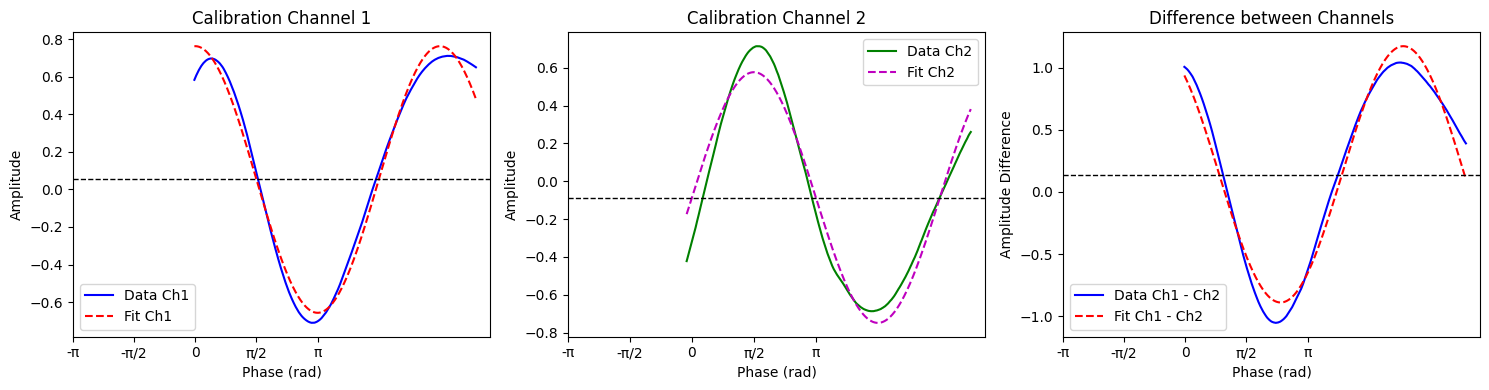

In [6]:
obj.calibrate_iq_amplitudes()
obj.plot_calibration()

In [7]:
obj.fit_result_calib_ch1.params.pretty_print()
print()
obj.fit_result_calib_ch2.params.pretty_print()

Name       Value      Min      Max   Stderr     Vary     Expr Brute_Step
amp       0.7103       -1        1 0.001373     True     None     None
freq       4.021        0       10  0.00674     True     None     None
offset   0.05291    -0.25     0.25  0.00154     True     None     None
phase     -2.437   -3.142    3.142  0.01026     True     None     None

Name       Value      Min      Max   Stderr     Vary     Expr Brute_Step
amp       0.6623        0        1 0.003014     True     None     None
freq       4.004        0       10 0.007522     True     None     None
offset  -0.08596    -0.25     0.25 0.002109     True     None     None
phase     -2.537   -2.537   -2.337  0.01249     True     None     None


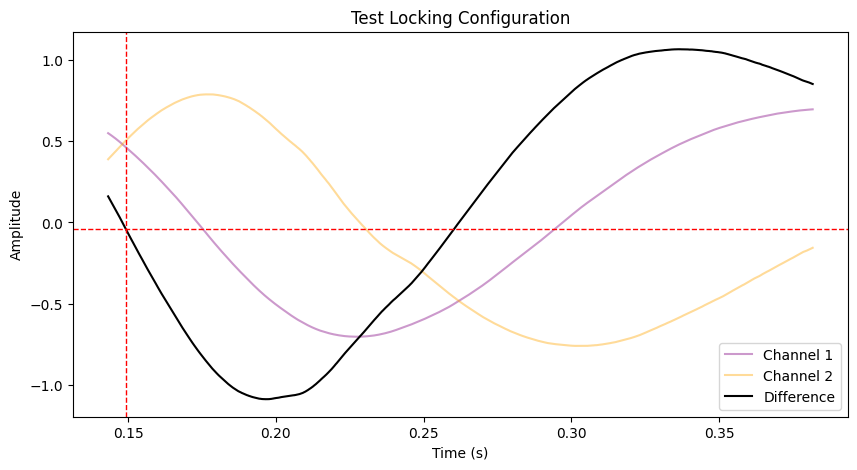

In [8]:
obj.setup_locking(phase_setpoint=np.pi/4)
obj.test_locking_configuration()

In [9]:
obj.lock()

In [12]:
time_data, in1_data, in2_data = obj.test_locking()

Input 1 was locked around 0.61 V with a standard deviation of 0.04 V
Input 2 was locked around 0.04 V with a standard deviation of 0.03 V


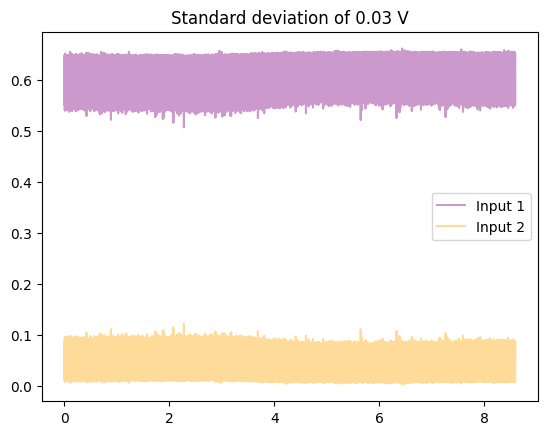

In [15]:
plt.figure()
plt.title(f"Standard deviation of {(np.std(in1_data) + np.std(in2_data)) / 2:.2f} V")
plt.plot(time_data, in1_data, label='Input 1', alpha=0.4, c='purple')
plt.plot(time_data, in2_data, label='Input 2', alpha=0.4, c='orange')
plt.legend()
# plt.ylim(0, 1)
# plt.xlim(0,0.01)
plt.show()

In [ ]:
import lmfit


obj.rp.asg0.output_direct = 'out1'
data = obj.rp.scope.save_curve()
time, iq0_data = data[0].data
time, iq1_data = data[1].data
time_filtered = time[np.logical_and(time > 0.2/obj.rp.asg0.frequency, time < 0.3/obj.rp.asg0.frequency)]
iq0_data_filtered = iq0_data[np.logical_and(time > 0.2/obj.rp.asg0.frequency, time < 0.3/obj.rp.asg0.frequency)]
iq1_data_filtered = iq1_data[np.logical_and(time > 0.2/obj.rp.asg0.frequency, time < 0.3/obj.rp.asg0.frequency)]

model_iq0 = Model(iq0_fit_function, independent_vars=['time'])
params_iq0 = model_iq0.make_params(amp=1, freq=0.5, phase=0, offset=0)
fit_result_iq0 = model_iq0.fit(iq0_data_filtered, params_iq0, time=time_filtered)

model_iq1 = Model(iq1_fit_function, independent_vars=['time'])
params_iq1 = model_iq0.make_params(amp=1, freq=0.5, phase=0, offset=0)
fit_result_iq1 = model_iq0.fit(iq1_data_filtered, params_iq1, time=time_filtered)

In [20]:
fit_result_iq0.params.pretty_print()
print()
fit_result_iq1.params.pretty_print()

Name       Value      Min      Max   Stderr     Vary     Expr Brute_Step
amp        0.362     -inf      inf 0.004717     True     None     None
freq       5.806     -inf      inf  0.04901     True     None     None
offset    0.3025     -inf      inf 0.004905     True     None     None
phase      -8.57     -inf      inf  0.07217     True     None     None

Name       Value      Min      Max   Stderr     Vary     Expr Brute_Step
amp       0.6648     -inf      inf 0.001563     True     None     None
freq       4.051     -inf      inf    0.013     True     None     None
offset   0.04684     -inf      inf 0.0008817     True     None     None
phase     -4.386     -inf      inf  0.01994     True     None     None


In [24]:
fit_result_iq0.success

True

In [21]:
(fit_result_iq0.params['phase'].value - fit_result_iq1.params['phase'].value)/np.pi

-1.331833782817885

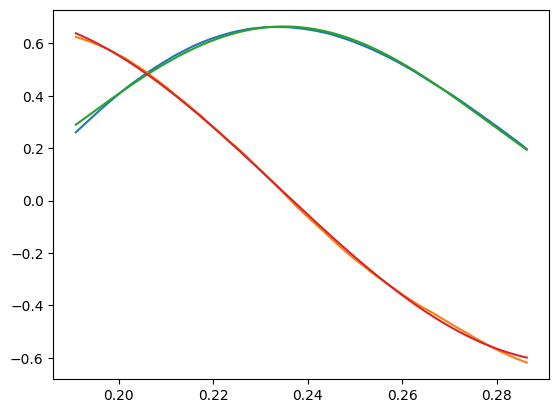

In [22]:
plt.plot(time_filtered, iq0_data_filtered)
plt.plot(time_filtered, iq1_data_filtered)
plt.plot(time_filtered, fit_result_iq0.best_fit)
plt.plot(time_filtered, fit_result_iq1.best_fit)

In [3]:
obj.rp.scope.duration

1.073741824

In [ ]:


with open("lockbox_config.yml", 'r') as stream:
    try:
        settings_dict = yaml.load(stream, Loader=CoreLoader)
    except yaml.YAMLError as exc:
        print(exc)


In [8]:
obj.rp.iq0.setup(**settings_dict['iqs']['iq0'])
obj.rp.iq1.setup(**settings_dict['iqs']['iq1'])
obj.rp.pid0.setup(**settings_dict['pids']['pid0'])
obj.rp.pid1.setup(**settings_dict['pids']['pid1'])
obj.rp.asg0.setup(**settings_dict['asgs']['asg0'])
obj.rp.asg1.setup(**settings_dict['asgs']['asg1'])
obj.rp.scope.setup(**settings_dict['scope'])

ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40100000 to _reads value 1 by client 3
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40100000 to _reads value 1 by client 7
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40100000 to _reads value 1 by client 9
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40100000 to _reads value 1 by client 13
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40100000 to _reads value 1 by client 19
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40100000 to _reads value 1 by client 23
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40100000 to _reads value 1 by client 25
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40100000 to _reads 

In [9]:
obj.rp.asg0.output_direct = 'out1'

In [6]:
obj.rp.scope.setup_attributes

OrderedDict([('trace_average', 1),
             ('curve_name', 'scope curve'),
             ('run_continuous', True),
             ('input1', 'iq0'),
             ('input2', 'iq1'),
             ('duration', 1.073741824),
             ('average', False),
             ('trigger_source', 'asg0'),
             ('trigger_delay', 0.0),
             ('threshold', 0.0),
             ('hysteresis', 0.0),
             ('ch1_active', True),
             ('ch2_active', True),
             ('ch_math_active', False),
             ('math_formula', 'ch1-ch2'),
             ('xy_mode', False),
             ('rolling_mode', False)])

In [17]:
obj.rp.pid0.setup_attributes

OrderedDict([('input', 'iq1'),
             ('output_direct', 'off'),
             ('setpoint', 0.0),
             ('p', 0.5),
             ('i', 0.1019044065621477),
             ('inputfilter', [0, 0, 0, 0]),
             ('max_voltage', 0.9998779296875),
             ('min_voltage', -1.0),
             ('pause_gains', 'pid'),
             ('paused', False),
             ('differential_mode_enabled', True)])